Проект 1: Оптимальная регуляризация в Ridge-регрессии и обусловливание матрицы (Strong Convexity)

1. ML-контекст: В линейных моделях скорость сходимости градиентного спуска напрямую зависит от числа обусловленности матрицы k = L/mu. Если признаки скоррелированы (мультиколлинеарность), X^T X близка к вырожденной, mu примерно равна 0 и метод «буксует». Добавление L2-регуляризации искусственно гарантирует сильную выпуклость.
2. ТеорияФункция потерь Ridge:L(w) = 1/2n ||Xw - y||{2}^{2} + a/2 ||w||{2}^{2}.
    1. Гессиан функции.
    2. Параметры гладкости и выпуклости: Константа Липшица градиента, а константа сильной выпуклости.
    3. Теоретический шаг: Оптимальный шаг градиентного спуска n = 2/L+mu

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Генерация "плохих" данных (мультиколлинеарность)
np.random.seed(42)
n, d = 500, 50
X = np.random.randn(n, d)
# Делаем признаки сильно зависимыми, зануляя часть сингулярных чисел
U, S, Vt = np.linalg.svd(X, full_matrices=False)
S[-10:] = 1e-5  # Делаем матрицу почти вырожденной
X = U @ np.diag(S) @ Vt
y = X @ np.random.randn(d) + np.random.randn(n) * 0.1


def run_experiment(alpha):
    # ТВОЙ КОД ЗДЕСЬ:
    # 1. Вычисли матрицу Гессиана H = (1/n) * X.T @ X + alpha * I
    H = (1 / n) * X.T @ X + alpha * np.eye(d)
    # 2. Найди L (макс. собств. значение H) и mu (мин. собств. значение H) через np.linalg.eigvalsh
    L = max(np.linalg.eigvalsh(H))
    mu = min(np.linalg.eigvalsh(H))
    # 3. Реализуй градиентный спуск с шагом eta = 2 / (L + mu) на 100 итераций
    eta = 2 / (L + mu)
    w = np.random.randn(d)  # стартовый вектор весов из случайных чисел
    history = []  # список, где записаны расстояния на каждой итерации
    # 4. Посчитай аналитический минимум w_opt через нормальное уравнение
    w_opt = np.linalg.solve(H, (X.T @ y) / n)  # функция которая точное решение системы линейных уравнений
    for _ in range(100):
        grad_L = (X.T @ (X @ w - y)) / n + alpha * w
        w = w - grad_L * eta  # обновляем веса
        history.append(np.linalg.norm(w - w_opt))  # считаем расстояние между идеальным вектором весов и нашим

    # 5. Верни историю расстояний до оптимума ||w_k - w_opt||_2 на каждом шаге
    return history


# ТВОЙ КОД ЗДЕСЬ:
# Запусти run_experiment для alpha = 0.0, alpha = 0.01, alpha = 0.5
# Построй график: по оси X - итерации, по оси Y - log(||w_k - w_opt||), 3 линии для разных alpha

In [ ]:
run_experiment(0.5)

[np.float64(3.0380877237023105),
 np.float64(1.673858408193301),
 np.float64(0.9761266036302886),
 np.float64(0.5826157823085536),
 np.float64(0.3528745300944063),
 np.float64(0.21585478930309315),
 np.float64(0.13294960747150794),
 np.float64(0.08228575170764729),
 np.float64(0.051107621485364914),
 np.float64(0.03182461983274328),
 np.float64(0.019854991337776524),
 np.float64(0.012405029995893338),
 np.float64(0.00775882192063358),
 np.float64(0.00485680935065573),
 np.float64(0.003042141407841226),
 np.float64(0.0019064143553508626),
 np.float64(0.0011951340249489446),
 np.float64(0.0007494465391319194),
 np.float64(0.0004700687793435863),
 np.float64(0.00029488817370761734),
 np.float64(0.00018501713958537136),
 np.float64(0.00011609471960272626),
 np.float64(7.285326146965833e-05),
 np.float64(4.572080853313837e-05),
 np.float64(2.8694669104329e-05),
 np.float64(1.8009693064863837e-05),
 np.float64(1.130382796988711e-05),
 np.float64(7.095059713098255e-06),
 np.float64(4.45344008

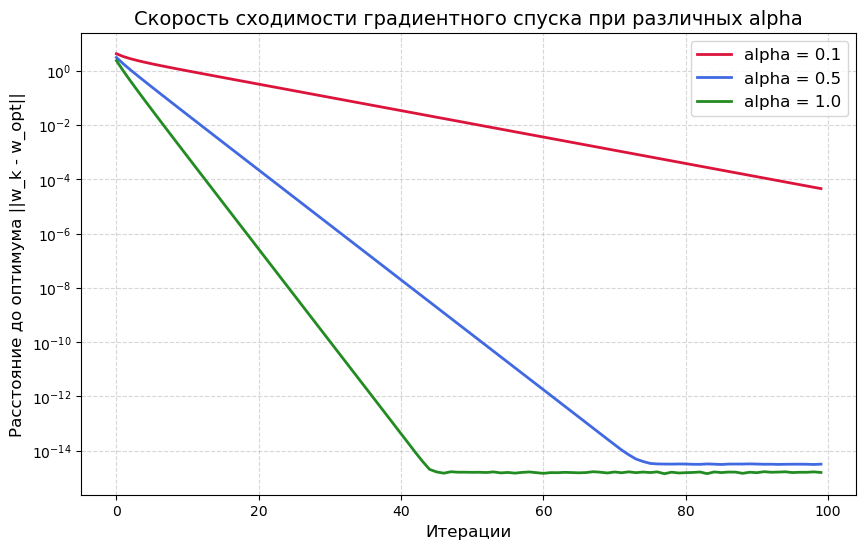

In [ ]:
import matplotlib.pyplot as plt

# 1. Запускаем эксперимент для разных alpha
history_01 = run_experiment(alpha=0.1)
history_05 = run_experiment(alpha=0.5)
history_10 = run_experiment(alpha=1.0)

# 2. Создаем график
plt.figure(figsize=(10, 6))

# Отрисовываем линии сходимости
plt.plot(history_01, label="alpha = 0.1", color="crimson", linewidth=2)
plt.plot(history_05, label="alpha = 0.5", color="royalblue", linewidth=2)
plt.plot(history_10, label="alpha = 1.0", color="forestgreen", linewidth=2)

# Настраиваем оси и сетку (БЕЗ спецсимволов доллара)
plt.yscale("log")
plt.xlabel("Итерации", fontsize=12)
plt.ylabel("Расстояние до оптимума ||w_k - w_opt||", fontsize=12)
plt.title("Скорость сходимости градиентного спуска при различных alpha", fontsize=14)

plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend(fontsize=12)

# Показываем график
plt.show()

Мост между теорией лекции и практикой
1. В лекции рассматривались дифференциальные критерии, свойства функций и то, как они влияют на скорость работы алгоритмов. Вот как это воплотилось в коде:
    1. Критерий сильной выпуклости через Гессиан:
        На лекции: Теория говорит, что если функция дважды дифференцируема, то она \(\mu \)-сильно выпукла тогда и только тогда, когда минимальное собственное значение её Гессиана не меньше \(\mu \) (\(\nabla^2 f(x) \succeq \mu I\)).
        На практике: Вы собрали матрицу Гессиана H и через функцию mu = min(np.linalg.eigvalsh(H)) вытащили эту самую теоретическую константу сильной выпуклости \(\mu \).
    2. Связь с регуляризацией (\(L_{2}\) / Ridge):
        На лекции: Мультиколлинеарность (зависимость признаков) делает матрицу \(X^{T}X\) вырожденной, из-за чего \(\mu_{old} = 0\), и чистая функция выпукла, но не сильно выпукла.
        На практике: Добавление слагаемого alpha * np.eye(d) искусственно сдвинуло спектр матрицы вверх. Благодаря этому mu стало строго больше нуля (\(\mu = \lambda_{min} + \alpha\)), гарантируя сильную выпуклость.
    3. Оптимальный шаг и число обусловленности:
        На лекции: Число обусловленности \(\kappa = L/\mu\) определяет «вытянутость оврага» функции. Зная границы кривизны ландшафта (\(L\) и \(\mu \)), можно рассчитать идеальный шаг \(\eta = \frac{2}{L+\mu}\), максимизирующий скорость сжатия ошибки.
        На практике: Вы рассчитали L и mu, задали этот оптимальный шаг eta и обеспечили алгоритму максимально возможную теоретическую скорость сходимости.

 Главные теоретические выводы (Что важно запомнить)Зачем нужен множитель \(\frac{1}{2n}\) перед Loss: \(1/n\) спасает масштаб ошибки и градиента от взрыва при увеличении объема данных (датасета), делая алгоритм масштабируемым. Константа \(1/2\) нужна чисто для математической красоты, чтобы сократить двойку при дифференцировании квадрата.Градиент vs Гессиан:Градиент (1-я производная) — вектор, указывающий направление наикрутейшего роста. Знак «минус» перед ним разворачивает нас в сторону спуска. Вычисляется на каждом шаге, так как направление постоянно меняется.Гессиан (2-я производная) — матрица, описывающая кривизну (крутизну) склонов. В квадратичных задачах (Ridge) она константна везде, поэтому мы считаем её всего 1 раз до цикла, чтобы узнать геометрию и зафиксировать идеальный размер шага eta.Линейная (геометрическая) сходимость: Благодаря тому, что \(\mu > 0\), график расстояния до оптимума np.linalg.norm(w - w_opt) в логарифмической шкале (plt.yscale('log')) покажет идеальную прямую линию. Ошибка падает в фиксированное число раз на каждом шаге.

Проект 2: Барьер перепараметризации в Deep Learning (Условие Поляка — Лоясиевича)


ML-контекст: Современные нейросети содержат миллионы параметров. Часто параметров гораздо больше, чем объектов в обучающей выборке (такие сети называют перепараметризованными). Их функция потерь не является выпуклой. На ландшафте есть куча плато и локальных седловых точек. Более того, у них нет одного минимума — существует бесконечно много комбинаций весов, которые дают нулевую ошибку (целые «долины» идеальных решений, где \(f^* = 0\)).Возникает парадокс: функция невыпуклая, минимумов много, но обычный градиентный спуск (SGD) находит решение мгновенно и сходится с огромной скоростью. Почему? Потому что вдоль траектории обучения выполняется условие Поляка — Лоясиевича (PL condition). Оно заменяет сильную выпуклость там, где ее физически не может быть.

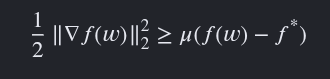

Оно требует, чтобы норма градиента росла пропорционально значению самой функции потерь. То есть: пока ошибка  большая, градиент обязан быть мощным. Алгоритм не может «застрять» или бесконечно буксовать на ровном месте, пока лосс не упадет. Как только мы приближаемся к минимуму и лосс стремится к нулю, градиент тоже плавно зануляется.

In [ ]:
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim

# 1. Генерируем задачу: параметров больше, чем объектов (n=20, d=100)
torch.manual_seed(42)
X = torch.randn(20, 100)
y = torch.randn(20, 1)

# Перепараметризованная сеть без активаций (линейная, но ландшафт от матриц весов невыпуклый!)
model = nn.Sequential(nn.Linear(100, 50, bias=False), nn.Linear(50, 1, bias=False))
criterion = nn.MSELoss()  # f^* = 0, так как параметров очень много

loss_history = []
pl_coefficient_history = []

optimizer = optim.SGD(model.parameters(), lr=0.01)

for epoch in range(150):
    optimizer.zero_grad()
    outputs = model(X)
    loss = criterion(outputs, y)
    loss.backward()

    # === ТВОЙ КОД ЗДЕСЬ ===
    # Подсказка по шагам:
    # 1. Соберите все градиенты параметров слоя в один плоский вектор.
    #    В PyTorch градиенты лежат в p.grad для каждого параметра p модели.
    #    Можно использовать: grads = [p.grad.view(-1) for p in model.parameters() if p.grad is not None]
    #    И объединить их через: all_grads = torch.cat(grads)
    grads = [p.grad.view(-1) for p in model.parameters() if p.grad is not None]
    all_grads = torch.cat(grads)
    # 2. Вычислите квадрат евклидовой нормы этого вектора градиентов.
    #    (Вспомните функцию torch.norm или просто сумму квадратов элементов)
    n = (torch.norm(all_grads)) ** 2
    # 3. Посчитайте текущий mu_k по формуле: (квадрат_нормы_градиента) / (2 * loss.item())
    mu_k = n / (2 * loss.item())
    # 4. Сохраните loss.item() в loss_history, а mu_k в pl_coefficient_history
    # ======================
    loss_history.append(loss.item())
    pl_coefficient_history.append(mu_k)
    optimizer.step()

# После того как напишете код, нужно будет построить два графика:
# 1. plt.yscale('log') для loss_history (проверить, прямая ли там линия)
# 2. Обычный график для pl_coefficient_history (посмотреть, падает ли он в 0)

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:19: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_15331/4245898891.py:17: SyntaxWarning: invalid escape sequence '\m'
  plt.plot(pl_coefficient_history, label='$\mu_k$ (PL-coefficient)', color='orange')
/tmp/ipykernel_15331/4245898891.py:19: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('Значение $\mu_k$')


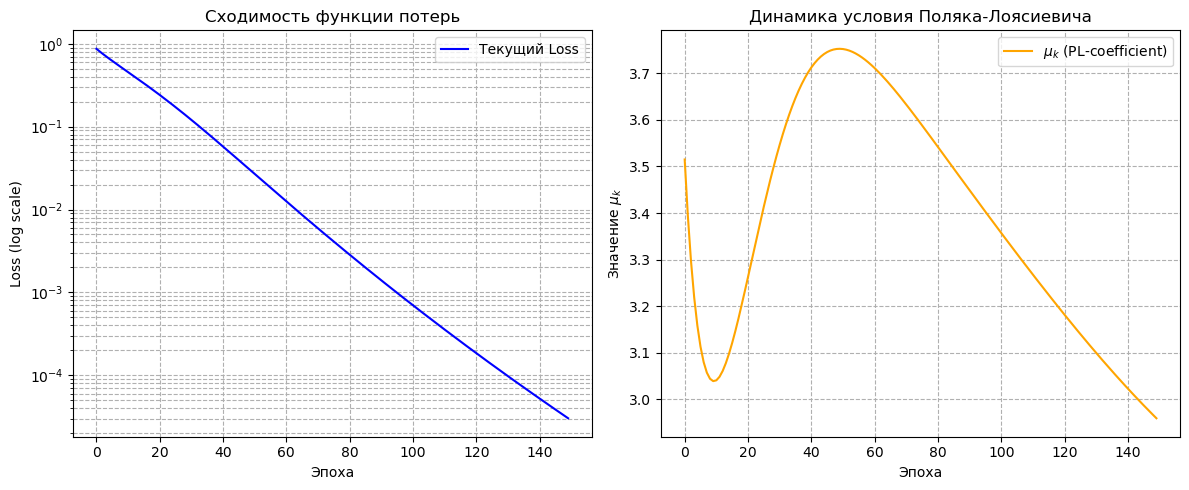

In [ ]:
import numpy as np

plt.figure(figsize=(12, 5))

# График 1: Сходимость функции потерь
plt.subplot(1, 2, 1)
plt.plot(loss_history, label="Текущий Loss", color="blue")
plt.yscale("log")  # Включаем логарифмический масштаб
plt.xlabel("Эпоха")
plt.ylabel("Loss (log scale)")
plt.title("Сходимость функции потерь")
plt.grid(True, which="both", ls="--")
plt.legend()

# График 2: Динамика PL-коэффициента mu_k
plt.subplot(1, 2, 2)
plt.plot(pl_coefficient_history, label="$\mu_k$ (PL-coefficient)", color="orange")
plt.xlabel("Эпоха")
plt.ylabel("Значение $\mu_k$")
plt.title("Динамика условия Поляка-Лоясиевича")
plt.grid(True, ls="--")
plt.legend()

plt.tight_layout()
plt.show()

Проект 3: Тест геометрии ландшафта (Matrix Factorization)

ML-контекст: В глубоком обучении и рекомендательных системах (например, SVD-разложение для предсказания рейтингов фильмов) мы часто раскладываем одну большую матрицу на произведение двух матриц меньшего ранга. Ландшафт таких задач невыпуклый, а глобальный минимум не единственный. Мы визуализируем этот ландшафт в простейшем двумерном случае, чтобы увидеть, как градиентный спуск сходится к разным точкам, но с одинаковой линейной скоростью.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def f(u, v):
    return 0.5 * (u * v - 1) ** 2


def grad_f(u, v):
    # === ТВОЙ КОД ЗДЕСЬ ===
    # Посчитай частные производные по формулам из теории:
    df_du = (u * v - 1) * v
    df_dv = (u * v - 1) * u
    return df_du, df_dv


def run_gd(start_point, lr=0.1, steps=30):
    u, v = start_point
    u_hist, v_hist = [u], [v]

    for _ in range(steps):
        df_du, df_dv = grad_f(u, v)
        # === ТВОЙ КОД ЗДЕСЬ ===
        # Сделай шаг градиентного спуска (вычти градиент с весом lr)
        u = u - lr * df_du
        v = v - lr * df_dv

        u_hist.append(u)
        v_hist.append(v)

    return np.array(u_hist), np.array(v_hist)


# Запуск из двух разных точек
u1, v1 = run_gd((2.0, 2.0))
u2, v2 = run_gd((-2.0, -0.5))

# === ТВОЙ КОД ЗДЕСЬ ===
# 1. Создай сетку координат через np.meshgrid от -3 до 3
# 2. Посчитай значение f(U, V) для всей сетки
u_range = np.linspace(-3, 3, 100)
v_range = np.linspace(-3, 3, 100)
U, V = np.meshgrid(u_range, v_range)
Z = f(U, V)
# 3. Построй линии уровня через plt.contour(U, V, Z, levels=20)
# 4. Наложи траектории: plt.plot(u1, v1, '-o') и plt.plot(u2, v2, '-o')
# 5. Выведи финальные точки и проверь, чему равно их произведение u * v

<>:12: SyntaxWarning: invalid escape sequence '\c'
<>:12: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_15331/3437851345.py:12: SyntaxWarning: invalid escape sequence '\c'
  plt.plot(u_true, 1/u_true, '--', color='red', alpha=0.5, label='Истинные минимумы ($u \cdot v = 1$)')


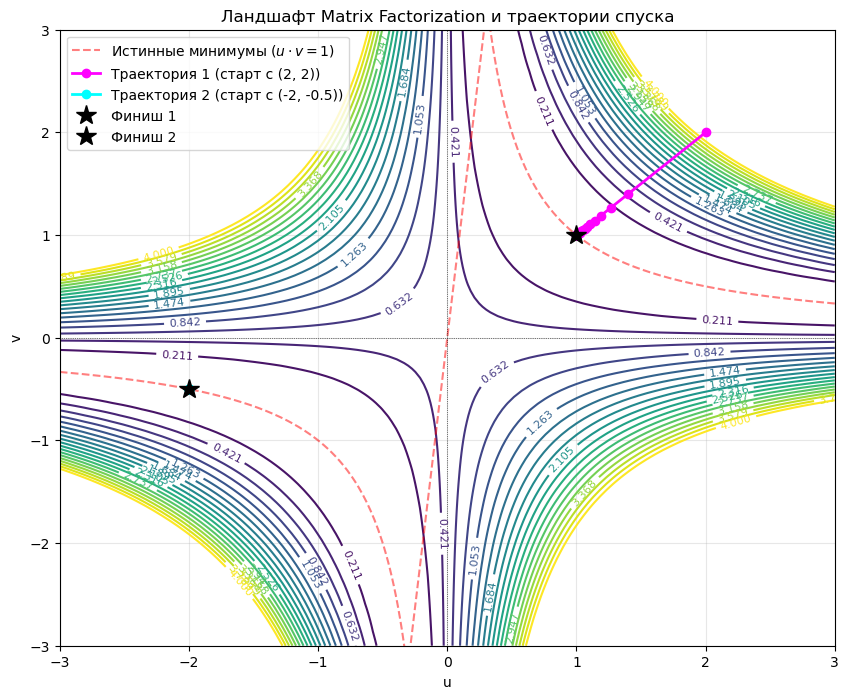

Финиш 1: u = 1.0003, v = 1.0003. Произведение u * v = 1.0007
Финиш 2: u = -2.0000, v = -0.5000. Произведение u * v = 1.0000


In [ ]:
plt.figure(figsize=(10, 8))

# 1. Строим линии уровня (ландшафт функции ошибок)
# levels=np.linspace(0, 4, 20) задает отображение уровней ошибки от 0 до 4
contours = plt.contour(U, V, Z, levels=np.linspace(0, 4, 20), cmap="viridis")
plt.clabel(contours, inline=True, fontsize=8)  # добавляет подписи значений ошибок на линии

# 2. Нарисуем истинную линию минимумов (гиперболу u * v = 1) для наглядности
u_true = np.linspace(-3, 3, 400)
# исключаем деление на ноль
u_true = u_true[np.abs(u_true) > 0.3]
plt.plot(u_true, 1 / u_true, "--", color="red", alpha=0.5, label="Истинные минимумы ($u \cdot v = 1$)")

# 3. Накладываем траектории градиентного спуска
plt.plot(u1, v1, "-o", color="magenta", linewidth=2, label="Траектория 1 (старт с (2, 2))")
plt.plot(u2, v2, "-o", color="cyan", linewidth=2, label="Траектория 2 (старт с (-2, -0.5))")

# 4. Отметим финальные точки звездочками
plt.plot(u1[-1], v1[-1], "*", color="black", markersize=15, label="Финиш 1")
plt.plot(u2[-1], v2[-1], "*", color="black", markersize=15, label="Финиш 2")

# Настройки осей и легенда
plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.xlabel("u")
plt.ylabel("v")
plt.title("Ландшафт Matrix Factorization и траектории спуска")
plt.axhline(0, color="black", linewidth=0.5, linestyle=":")
plt.axvline(0, color="black", linewidth=0.5, linestyle=":")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

# === Численная проверка вывода лекции ===
print(f"Финиш 1: u = {u1[-1]:.4f}, v = {v1[-1]:.4f}. Произведение u * v = {u1[-1]*v1[-1]:.4f}")
print(f"Финиш 2: u = {u2[-1]:.4f}, v = {v2[-1]:.4f}. Произведение u * v = {u2[-1]*v2[-1]:.4f}")